# Slow farmer Kolmogorov equations for $N_w$ and $N_g$

In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [2]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [3]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [4]:
R = 0.00888
K = 0.00772

## setting up system

In [5]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<=t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [6]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

In [7]:
def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

In [8]:
#s matrix elements

def s_ijkl(i, j, k, l, N, A):

    if i == k and j == l:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    elif i == k-1 and j == l:
        return growthRate(k-1, N, A)
    elif i == k+1 and j == l:
        return eatRate(k+1, N, A)*l/N
    elif i == k+1 and j == l-1:
        return eatRate(k+1, N, A)*(N-l+1)/N
    else:
        return 0

In [9]:
def sMatrix(N, A):
    s_matrix = np.zeros((A+1, N+1, A+1, N+1))
    for i in range(A+1):
        for j in range(N+1):
            for k in range(A+1):
                for l in range(N+1):
                    s_matrix[i,j,k,l] = s_ijkl(i, j, k, l, N, A)
    return s_matrix

In [10]:
def sFlatten(s):
    """accepts matrix of shape (A+1, N+1, A+1, N+1)
    reshape into matrix of shape ( (A+1)(N+1), (A+1)(N+1) )
    does not need N and A passed to it because dimensions can be grabbed
    from s.shape
    """

    #dim = (A+1)(N+1)
    dim = s.shape[0]*s.shape[1]

    #fortran order
    return np.reshape(s, (dim, dim), "f")

def qFlatten(q):
    """accepts matrix of shape (A+1, N+1)
    reshape into matrix of shape (A+1)*(N+1)
    """

    dim = q.shape[0]*q.shape[1]

    return np.reshape(q, (dim), "f")

def qExpand(q, N, A):
    """accepts q vector of shape (A+1)*(N+1)
    reshape into matrix (A+1, N+1)
    needs N and A passed to it
    """

    return np.reshape(q, (A+1, N+1), "f")

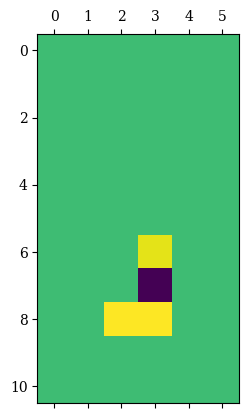

In [11]:
f, ax = plt.subplots()

ax.matshow(sMatrix(5, 10)[:, :, 7, 3])

## quasi-equilibrium distribution
used for initial condition for slow farmer

In [12]:
def quasiEqRec(A, N):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    #concatenate a zero to the beginning to represent p_0=0
    #important for use with pmfE() and pmfVar(), which assume that p_i appears at index i
    return np.concatenate((np.array([0]), np.linalg.solve(mat, b)))

## setting up simulation

requires fast farmer to have been run

In [13]:
def getInit(N):
    """fetch the numerical solution for the N_g distribution from the fast farmer kolmogorov equations"""

    with open("kolmogorov_sol_100.dat", "rb") as f:
        sol_100 = pickle.load(f)

    #get the solution at final time
    return sol_100[str(N)]["y"][:,-1]

In [49]:
def simulate(N, A, stoptime, init="quasi"):

    s_matrix = sMatrix(N, A)

    q0 = np.zeros((A+1, N+1))
    #begin pasture Nw=0
    #and Ng is quasi-equilibrium
    #meaning q_x,0 = p_x at equilibrium
    if init=="quasi":
        q0[:,0]=quasiEqRec(A, N)
    elif init=="max":
        q0[A,0]=1

    #need to reshape to work with solve_ivp
    #fortran order - first index changes fastest
    s_matrix = sFlatten(s_matrix)
    q0 = np.reshape(q0, ((N+1)*(A+1)), order="F")

    def sys(t, y):
        return np.matmul(y, s_matrix)

    #t_list needs to be specified here to ensure dense data at small T
    #we are gonna be interested in computing F_slow at T=1 and if we don't
    #specify t_list, we will not have points sufficiently close to T=1
    t_list = np.concatenate((np.arange(0, 11), np.arange(20, 100, 10), np.arange(100, stoptime+1, 100)))
    
    st = time.time()

    s = sp.integrate.solve_ivp(sys, (0, stoptime), q0, method="RK23", t_eval=t_list)
    print("finished in {0} seconds".format(time.time()-st))

    return s

## simpler plot of q evolution

In [71]:
sol = simulate(15, 30, 1000, "max")

data1 = qExpand(sol["y"][
                   :,timeToIndex(
                       sol["t"], 20)], 15, 30)

data2 = qExpand(sol["y"][
                   :,timeToIndex(
                       sol["t"], 100)], 15, 30)

data3 = qExpand(sol["y"][
                   :,timeToIndex(
                       sol["t"], 500)], 15, 30)

finished in 0.0184023380279541 seconds


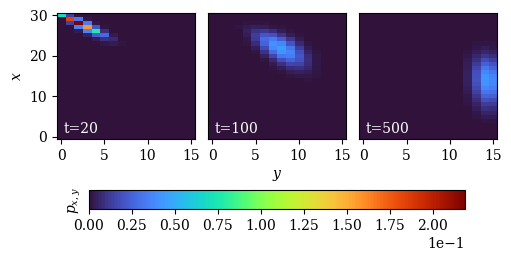

In [79]:
f, axs = plt.subplots(ncols=3, figsize=(5, 2.5), layout="constrained")

vm = np.max([
    data1,
    data2,
    data3])

ptr = axs[0].imshow(data1, aspect="auto", origin="lower", vmax=vm, cmap="turbo")
axs[1].imshow(data2, aspect="auto", origin="lower", vmax=vm, cmap="turbo")
axs[2].imshow(data3, aspect="auto", origin="lower", vmax=vm, cmap="turbo")

axs[1].set_xlabel("$y$")
axs[0].set_ylabel("$x$")
axs[1].set_yticks([])
axs[2].set_yticks([])

axs[0].set_xticks([0, 5, 10, 15])
axs[1].set_xticks([0, 5, 10, 15])
axs[2].set_xticks([0, 5, 10, 15])

axs[0].annotate("t=20", (0.05, 0.05), xycoords="axes fraction", color="white")
axs[1].annotate("t=100", (0.05, 0.05), xycoords="axes fraction", color="white")
axs[2].annotate("t=500", (0.05, 0.05), xycoords="axes fraction", color="white")

cb = plt.colorbar(ptr, ax=axs, location="bottom")
cb.formatter.set_powerlimits((-1, 5))
cb.ax.set_ylabel("$p_{x,y}$")

plt.savefig("p_nw_evolution.pdf")

## Simulate a range of pastures

In [30]:
#like for the fast farmer, test values of N from 0.05A up to 0.85A in increments of 0.05A
#test only A=100
#test out to t=1600

sol_100 = {str(i): simulate(i, 100, 1600) for i in range(5, 90, 5)}

finished in 0.046300411224365234 seconds
finished in 0.13388919830322266 seconds
finished in 0.9408137798309326 seconds
finished in 2.0235595703125 seconds
finished in 3.6310853958129883 seconds
finished in 5.398380517959595 seconds
finished in 8.473915815353394 seconds
finished in 11.949972867965698 seconds
finished in 16.081174850463867 seconds
finished in 21.844106674194336 seconds
finished in 27.263739347457886 seconds
finished in 34.58922743797302 seconds
finished in 42.53880333900452 seconds
finished in 50.44533610343933 seconds
finished in 61.520723819732666 seconds
finished in 69.91634035110474 seconds
finished in 83.2099380493164 seconds


In [11]:
with open("slow_sol_100.dat", "rb") as f:
    sol_100 = pickle.load(f)

## plot evolution of q

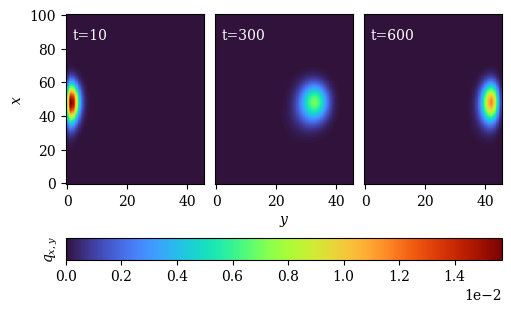

In [32]:
f, axs = plt.subplots(nrows=1, ncols=3, figsize=(5, 3), layout="constrained")

axs = np.reshape(axs, 3)

n=45

data1 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 10)], n, 100)

data2 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 300)], n, 100)

data3 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 600)], n, 100)

#max q
#to use the same color scale in each image
vm = np.max([
    np.max(data1),
    np.max(data2),
    np.max(data3)])

for i in range(0,3):
    ptr = axs[i].imshow([data1, data2, data3][i],
                           origin="lower",
                           aspect="auto",
                           cmap="turbo",
                           vmin=0, vmax=vm)

    #axs[i].set_xticks([0, 10, 20, 30, 40])
    axs[i].annotate("t={0}".format([10, 300, 600][i]), (0.05, 0.85),
                    xycoords="axes fraction", color="white")

axs[1].set_xlabel("$y$")
axs[0].set_ylabel("$x$")
axs[1].set_yticks([])
axs[2].set_yticks([])

cb = plt.colorbar(ptr, ax=axs, location="bottom")
cb.formatter.set_powerlimits((-1, 5))
cb.ax.set_ylabel("$q_{x,y}$")

plt.savefig("q_evolution.pdf")

## Plot example contour of q

ValueError: cannot reshape array of size 3 into shape (4,)

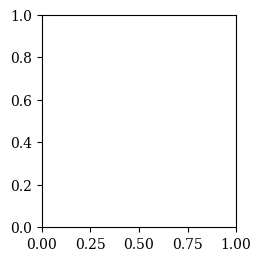

In [33]:
f, ax = plt.subplots(figsize=(2.5, 2.5), layout="constrained")

axs = np.reshape(axs, 4)

n=50

data1 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 200)], n, 100)

ptr = ax.contour(np.abs(data1), origin="lower", colors="#000000", levels=5)

ax.axis([10, 40, 20, 70])

ax.set_xticks([10, 20, 30, 40])
ax.set_xlabel("$y$")
ax.set_ylabel("$x$")
ax.annotate("t=200", (0.05, 0.85), xycoords="axes fraction", color="white")

ax.grid(True)

#plt.savefig("q_evolution.pdf")

## plot evolution of $\sum_{x}q_{x,y}$
i.e. the PMF of $N_w$, summed across all values of $N_g$

In [19]:
def nwpmf(qxy, N, A):
    """accept flattened bivariate pmf qxy, and N and A values
    unflatten qxy into (A+1)x(N+1) array and sum over the Ng axis"""
    return np.sum(qExpand(qxy, N, A), axis=0)

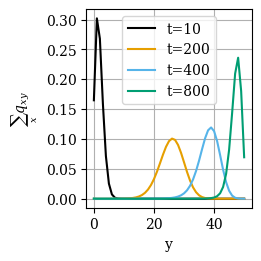

In [20]:
f, ax = plt.subplots(layout="constrained", figsize=(2.5, 2.5))

ax.set_prop_cycle(wong_cycle)

for i in [10, 200, 400, 800]:
    ax.plot(nwpmf(sol_100["50"]["y"][:,timeToIndex(sol_100["50"]["t"], i)], 50, 100), label="t={0}".format(i))

ax.grid(True)
ax.set_xlabel("y")
ax.set_ylabel("$\sum_{x}q_{xy}$")
ax.legend(loc="upper center")

#plt.savefig("q_nw_evolution.pdf")

## F_slow plots

In [21]:
def expectedNw(qxy, N, A):
    """accept flattened bivariate pmf qxy, and N and A values
    calculate expected value of Nw by expanding qxy, summing over
    Ng axis, and finding expected value"""
    return pmfE(nwpmf(qxy, N, A))

def f_slow(soln, N, A, T):
    """soln: entire dict of sp.integrate.solve_ivp() output
    
    find expected Nw at time T, divide by T and return"""

    #need because for small T, soln may not actually have data at t close to T
    t_index = timeToIndex(soln["t"], T)

    return expectedNw(soln["y"][:,t_index], N, A)/soln["t"][t_index]

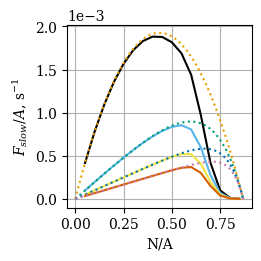

In [70]:
times = [1, 500, 1000, 1500]

f_slow_100 = {
    t: np.array([f_slow(
        sol_100[n], int(n), 100, t
    ) for n in sol_100.keys()]
               ) for t in times
}

with open("f_slow_100_unsimplified.dat", "wb") as f:
    pickle.dump(f_slow_100, f)

f, ax = plt.subplots(layout="constrained", figsize=(2.5, 2.5))

ax.set_prop_cycle(wong_cycle)

def fslow_det(N, A, T):
    """deterministic F_slow"""
    return (N-N*np.exp(-T*R+T*R*R*N/(A*K)))/T

for k in times:
    ax.plot(np.arange(5, 90, 5)/100, f_slow_100[k]/100, "-", label="T={0}".format(k))
    #ax.plot(np.arange(3, 52, 3)/60, f_slow_60[k]/60, "-")
    ax.plot(np.arange(0, 88)/100, fslow_det(np.arange(0, 88), 100, k)/100, ":")

#ax2.plot(np.arange(6, 103, 6)/120, f_slow_120[1]/120, "-", label="T=1")
#ax2.plot(np.arange(3, 52, 3)/60, f_slow_60[1]/60, "-")
#ax2.plot(np.arange(0, 103)/120, fslow_det(np.arange(0, 103), 120, 1)/120, ":")

ax.grid(True)
ax.set_xlabel("N/A")
ax.set_ylabel("$F_{slow}/A$, s$^{-1}$")
ax.ticklabel_format(scilimits=(-2,5))